# 1.3. DataPrep: Cell viability
# 1.3. 数据准备：细胞活力

### 📘 Overview
### 📘 概述

This notebook processes raw viability assay data and performs dose–response curve fitting to estimate the IC₁₀ value (concentration causing ≥10% viability reduction) for each compound.
这个notebook处理原始细胞活力实验数据，并进行剂量-反应曲线拟合，以估计每个化合物的IC₁₀值（导致≥10%活力降低的浓度）。

**Inputs**  
**输入数据**  
Raw viability assay data across multiple doses  
跨多个剂量的原始细胞活力实验数据

**Output**  
**输出**  
A CSV file containing IC₁₀ estimates per compound
一个包含每个化合物IC₁₀估计值的CSV文件  

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import dilimap as dmap

In [2]:
dmap.logging.print_version()

Running dilimap 0.2.dev20+gc285bd842 (python 3.10.19) on 2025-11-20 01:15.


## Load raw data
## 加载原始数据

从S3读取原始细胞活力实验数据。

In [3]:
df = dmap.s3.read('compound_cell_viability_raw.csv')

Package: s3://dilimap/public/data. Top hash: 155a2b3b63


In [4]:
df.tail()

,Dose_uM,Raw Data Result,Result,Plate Name,Location
Compound,,,,,
Trientine Hydrochloride,0.0025,0.4117,88.014,C2_M1_T3,G05
Trientine Hydrochloride,0.0025,0.4104,88.052,C2_M1_T3,G06
Pyrimethamine,0.0025,0.4312,87.446,C2_M1_T3,G10
Pyrimethamine,0.0025,0.4046,88.220,C2_M1_T3,G11
Pyrimethamine,0.0025,0.5140,85.035,C2_M1_T3,G12


## Estimate IC10s
## 估计IC10值

通过剂量-反应曲线拟合估计每个化合物的IC10值（导致10%细胞活力降低的浓度）。

In [ ]:
for k in set(df['Plate Name']):
    # 对每个实验板进行处理
    plate_dmso_viability = df.loc[
        (df['Plate Name'] == k) & (df.index == 'DMSO'), 'Result'
    ].mean()
    # 计算该板中DMSO（对照）的平均活力值

    df.loc[df['Plate Name'] == k, 'viability_cutoff_IC20'] = plate_dmso_viability * 0.8
    # IC20阈值：DMSO活力的80%（即20%活力降低）
    df.loc[df['Plate Name'] == k, 'viability_cutoff_IC10'] = plate_dmso_viability * 0.9
    # IC10阈值：DMSO活力的90%（即10%活力降低）

In [ ]:
df_cmpds = (
    df.groupby(['Compound'])[['viability_cutoff_IC20', 'viability_cutoff_IC10']]
    .mean()
    .round(2)
)
# 按化合物分组，计算IC20和IC10阈值的平均值

df_crosstab = (
    pd.crosstab(
        df.index,
        df['Dose_uM'],
        df['Result'] < df['viability_cutoff_IC20'],
        aggfunc=np.mean,
    )
    < 0.5
)
# 创建交叉表：检查每个化合物在每个剂量下是否低于IC20阈值
# 如果平均低于阈值的比例<0.5，则认为该剂量未达到IC20
df_cmpds['MTD_IC20'] = df_cmpds.index.map((df_crosstab * df_crosstab.columns).max(1))
# 计算最大耐受剂量（MTD）IC20：找到未达到IC20的最高剂量

df_crosstab = (
    pd.crosstab(
        df.index,
        df['Dose_uM'],
        df['Result'] < df['viability_cutoff_IC10'],
        aggfunc=np.mean,
    )
    < 0.5
)
# 创建交叉表：检查每个化合物在每个剂量下是否低于IC10阈值
df_cmpds['MTD_IC10'] = df_cmpds.index.map((df_crosstab * df_crosstab.columns).max(1))
# 计算最大耐受剂量（MTD）IC10：找到未达到IC10的最高剂量

/var/folders/fh/r5412d0d6tl262nd_38k08d80000gp/T/ipykernel_34961/312586047.py:8: FutureWarning: The provided callable <function mean at 0x10362f5b0> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  pd.crosstab(
/var/folders/fh/r5412d0d6tl262nd_38k08d80000gp/T/ipykernel_34961/312586047.py:19: FutureWarning: The provided callable <function mean at 0x10362f5b0> is currently using DataFrameGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  pd.crosstab(


/var/folders/fh/r5412d0d6tl262nd_38k08d80000gp/T/ipykernel_34961/4241662078.py:81: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '81.08' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_cmpds.loc[cmpd, f'{cutoff[-4:]}_uM'] = (
/var/folders/fh/r5412d0d6tl262nd_38k08d80000gp/T/ipykernel_34961/4241662078.py:81: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '142.61' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_cmpds.loc[cmpd, f'{cutoff[-4:]}_uM'] = (


Sulfacarbamide: No optimal parameters found, using prior estimate instead


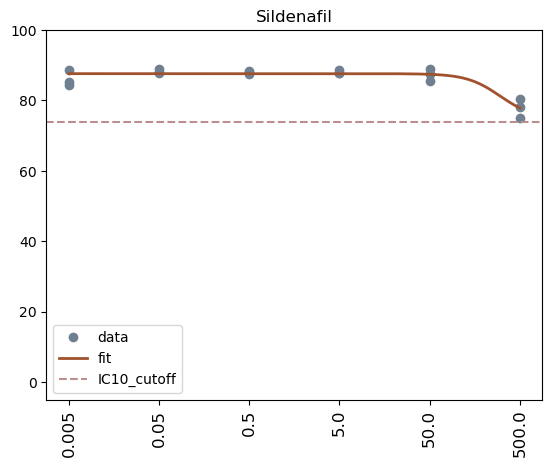

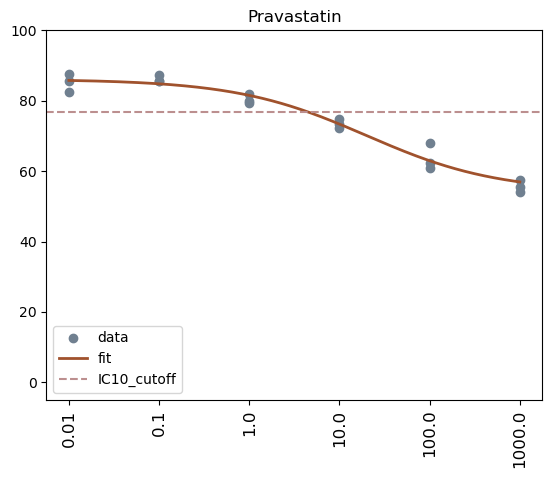

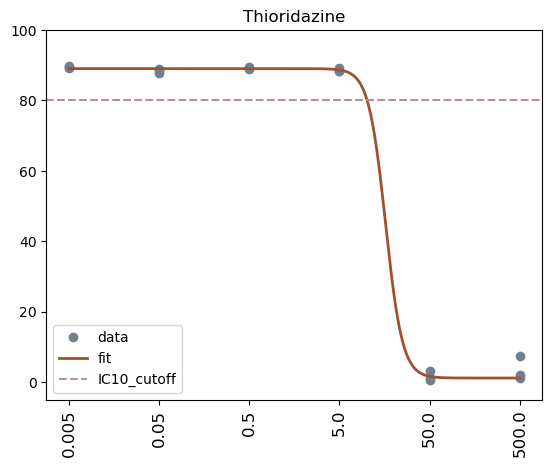

Vorinostat: No optimal parameters found, using prior estimate instead
Felbamate: No optimal parameters found, using prior estimate instead
Valproic acid: No optimal parameters found, using prior estimate instead
Propantheline: No optimal parameters found, using prior estimate instead
Oxcarbazepine: No optimal parameters found, using prior estimate instead


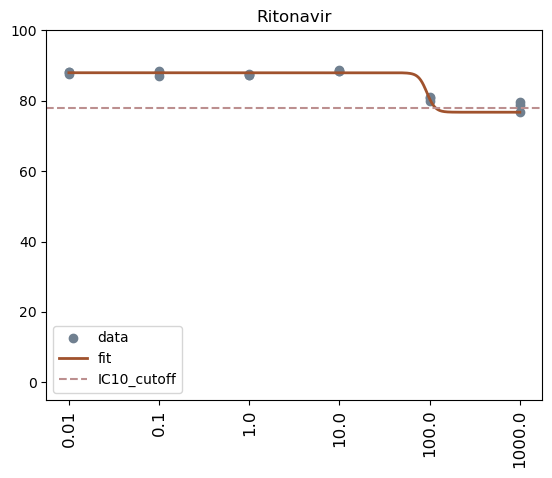

/opt/miniconda3/envs/dilimap/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/miniconda3/envs/dilimap/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)


Isosorbide Dinitrate: No optimal parameters found, using prior estimate instead


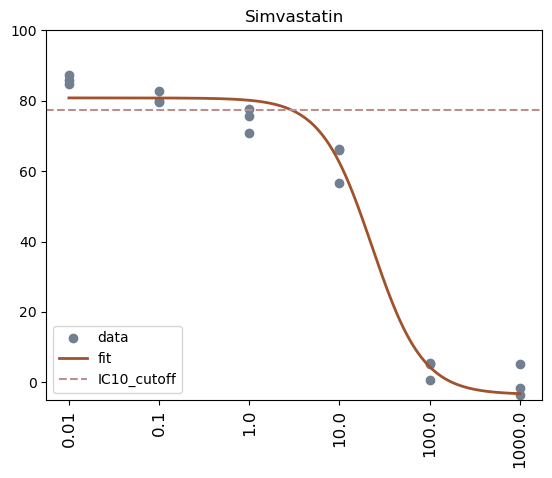

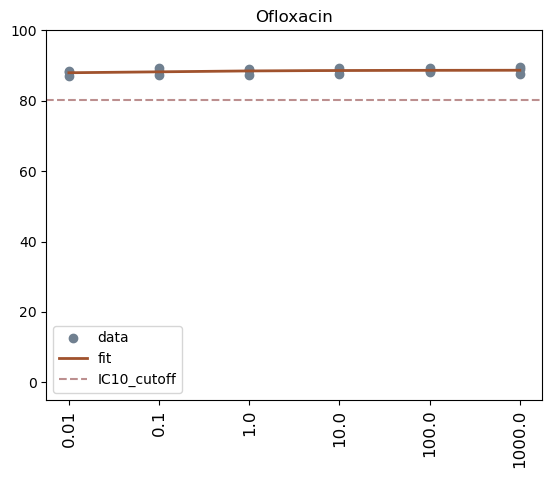

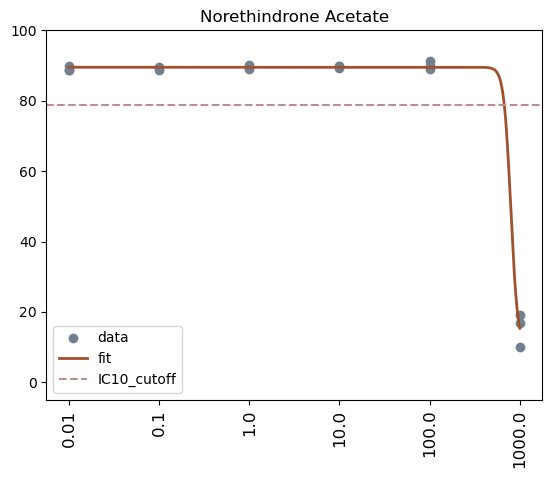

/opt/miniconda3/envs/dilimap/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)


Saxagliptin: No optimal parameters found, using prior estimate instead
Zonisamide: No optimal parameters found, using prior estimate instead


/opt/miniconda3/envs/dilimap/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)


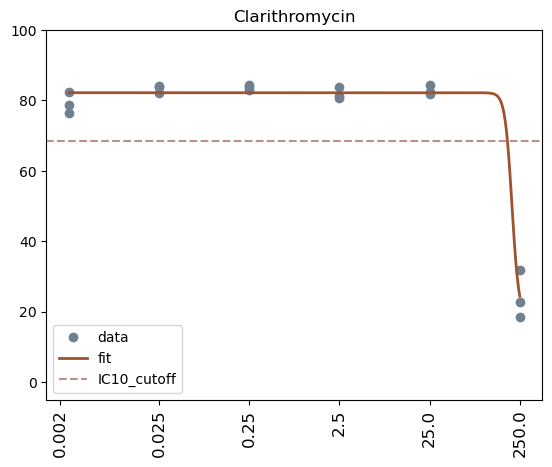

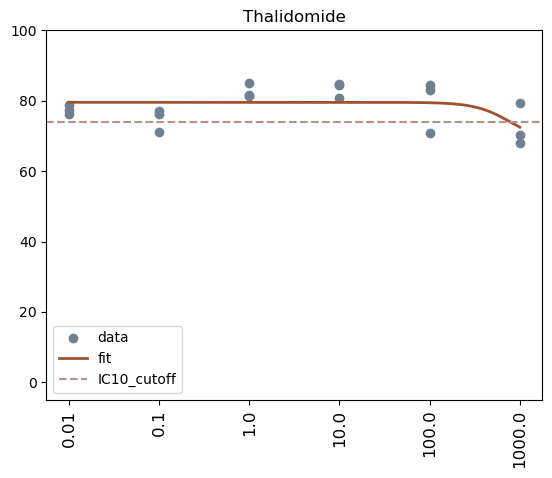

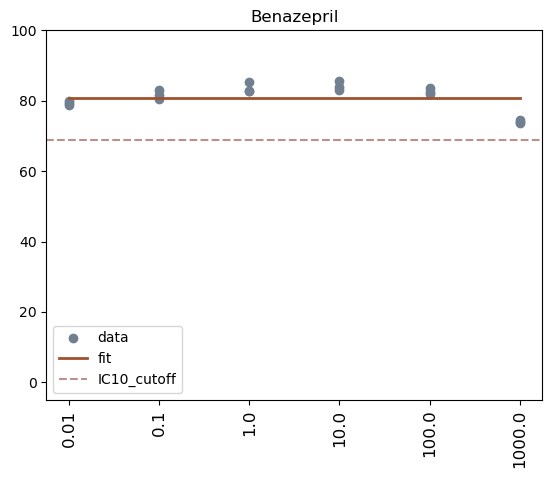

Busulfan: No optimal parameters found, using prior estimate instead


/opt/miniconda3/envs/dilimap/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)


Lomustine: No optimal parameters found, using prior estimate instead


/opt/miniconda3/envs/dilimap/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)


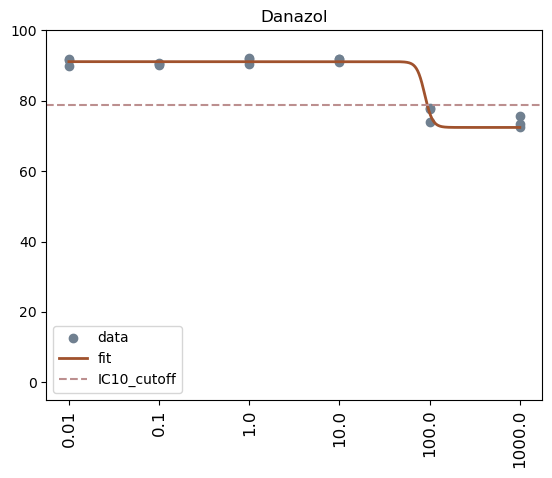

Acarbose: No optimal parameters found, using prior estimate instead


/opt/miniconda3/envs/dilimap/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/miniconda3/envs/dilimap/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/miniconda3/envs/dilimap/lib/python3.10/site-packages/numpy/core/function_base.py:158: RuntimeWarning: invalid value encountered in multiply
  y *= step
/opt/miniconda3/envs/dilimap/lib/python3.10/site-packages/numpy/core/function_base.py:168: RuntimeWarning: invalid value encountered in add
  y += start


In [ ]:
from scipy.optimize import curve_fit


def plot_curve_fit(x, y, popt=None, ic10=None, title=None):
    # 绘制剂量-反应曲线拟合图
    plt.plot(x, y, 'o', color='slategrey', markersize=6, label='data')
    # 绘制原始数据点

    ## errorbar
    # 误差条（已注释）
    # df_groupby = pd.DataFrame([x.values,y.values], index=['x', 'y']).T.groupby('x')
    # plt.errorbar(df_groupby.mean().index, df_groupby['y'].mean(), yerr=2*df_groupby['y'].std(), ecolor='navy', elinewidth=2, fmt='none')

    if popt is not None:
        # 如果有拟合参数，绘制拟合曲线
        xlin = np.linspace(x.min(), x.max(), 1000)
        # 生成平滑的x值用于绘制曲线
        fit = sigmoid(xlin, *popt)
        # 计算拟合曲线
        plt.plot(xlin, fit, 'sienna', lw=2, label='fit')
        # 绘制拟合曲线

    if ic10 is not None:
        # 如果有IC10阈值，绘制水平线
        plt.axhline(ic10, linestyle='--', color='rosybrown', label='IC10_cutoff')
        # 绘制IC10阈值线

    plt.ylim(-5, 100)
    # 设置y轴范围
    plt.legend(loc='lower left')
    # 显示图例
    plt.title(title)
    # 设置标题

    xticks = np.round(10 ** np.arange(x.min(), x.max() + 1), 3)
    # 生成x轴刻度（对数转换回原始值）
    plt.xticks(ticks=np.log10(xticks), labels=xticks, fontsize=12, rotation=90)
    # 设置x轴刻度和标签

    plt.show()


for cmpd in list(set(df.index)):
    ## prepare data
    ## 准备数据

    df1 = df[df.index == cmpd]
    # 获取该化合物的所有数据

    x = np.log10(df1['Dose_uM'])
    # 剂量（对数转换）
    y = np.clip(df1['Result'], 0, 100)
    # 活力结果（限制在0-100之间）
    y = df1['Result']
    # 使用原始结果（不裁剪）

    ymax = max(y)
    # 最大活力值
    ymin = min(y[x == x.max()])
    # 最高剂量下的最小活力值
    xmid = np.median(x)
    # 中位剂量（对数）
    ic10 = df1['viability_cutoff_IC10'].mean()
    # IC10阈值

    ## curve fit
    ## 曲线拟合

    def sigmoid(x, L, x0, k):
        # S型（Sigmoid）函数：用于拟合剂量-反应曲线
        # L: 最大响应值, x0: 中点, k: 斜率
        y = L / (1 + np.exp(k * (x - x0))) + ymin
        return y

    def sigmoid_fit(x, y, p0):
        # 拟合S型曲线
        return curve_fit(sigmoid, x, y, p0, method='dogbox')

    try:
        # 尝试使用初始参数进行拟合
        p0 = [ymax, xmid, 1]
        # 初始参数：[最大响应, 中点, 斜率]
        popt, _ = sigmoid_fit(x, y, p0)
    except Exception:
        try:
            # 如果失败，尝试调整中点参数
            p0 = [ymax, xmid * 2, 1]
            popt, _ = sigmoid_fit(x, y, p0)
        except Exception:
            try:
                # 如果仍然失败，尝试不使用裁剪的数据
                y_noclip = df1['Result']  # without clipping
                # 不使用裁剪的数据
                p0 = [ymax, xmid, 1]
                popt, _ = sigmoid_fit(x, y_noclip, p0)
            except Exception:
                try:
                    # 如果仍然失败，调整最大响应值
                    p0 = [max(ymax - ymin, 0), xmid, 1]
                    popt, _ = sigmoid_fit(x, y, p0)
                except Exception:
                    # 如果所有尝试都失败，使用初始估计值
                    print(
                        f'{cmpd}: No optimal parameters found, using prior estimate instead'
                    )
                    # 打印警告信息
                    popt = p0

    ## estimate IC10
    ## 估计IC10

    xlin = np.linspace(x.min(), x.max(), 1000)
    # 生成平滑的x值
    ylin = sigmoid(xlin, *popt)
    # 计算拟合曲线上的y值

    for cutoff in ['viability_cutoff_IC10', 'viability_cutoff_IC20']:
        # 对IC10和IC20阈值分别计算
        idx_tox = ylin < df1[cutoff].mean()
        # 找到拟合曲线上低于阈值的点
        df_cmpds.loc[cmpd, f'{cutoff[-4:]}_uM'] = (
            '{:.2f}'.format(10 ** xlin[idx_tox].min()) if sum(idx_tox) > 0 else np.nan
        )
        # 计算IC10或IC20值（将对数转换回原始浓度，单位：μM）

    ## viability curve examples
    ## 细胞活力曲线示例

    # if cmpd in ['Febuxostat', 'Perphenazine', 'Oxcarbazepine']:
    #    plot_curve_fit(x, y, popt, ic10, title=cmpd)
    # 可以取消注释来绘制特定化合物的曲线

    # list of cmpds we wanted to double-check with wetlab team
    # 需要与湿实验室团队再次确认的化合物列表
    if cmpd in [
        'Clarithromycin',
        'Benazepril',
        'Danazol',
        'Norethindrone Acetate',
        'Ofloxacin',
        'Pravastatin',
        'Ritonavir',
        'Sildenafil',
        'Simvastatin',
        'Thalidomide',
        'Thioridazine',
    ]:
        plot_curve_fit(x, y, popt, ic10, title=cmpd)
        # 绘制这些化合物的拟合曲线

In [ ]:
# Manual annotations pulled form Dotmatics
# 从Dotmatics系统手动提取的注释

df.loc['AKN-028'] = {'MTD_IC10': 50, 'IC10_uM': 500}
df.loc['BMS-986142'] = {'MTD_IC10': 100, 'IC10_uM': 1000}
df.loc['Evobrutinib'] = {'MTD_IC10': 50, 'IC10_uM': 500}
df.loc['TAK-875'] = {'MTD_IC10': 50, 'IC10_uM': 200}
df.loc['Ibrutinib'] = {'MTD_IC10': 10, 'IC10_uM': 100}
df.loc['Orelabrutinib'] = {'MTD_IC10': 100, 'IC10_uM': 1000}
df.loc['Remibrutinib'] = {'MTD_IC10': np.nan, 'IC10_uM': np.nan}
df.loc['Rilzabrutinib'] = {'MTD_IC10': 10, 'IC10_uM': 100}
df.loc['Ruxolitinib'] = {'MTD_IC10': np.nan, 'IC10_uM': np.nan}
df.loc['Tofacitinib'] = {'MTD_IC10': np.nan, 'IC10_uM': np.nan}
df.loc['Upadacitinib'] = {'MTD_IC10': np.nan, 'IC10_uM': np.nan}
# 为某些化合物手动添加IC10值（这些化合物可能没有实验数据或数据不完整）

## Push file to S3
## 将文件推送到S3

保存处理后的细胞活力数据到S3存储，供后续使用。

In [9]:
# dmap.s3.write(df, 'compound_cell_viability_IC10.csv')